In [16]:
from pathlib import Path
import sys

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import FEATURES
from src.clustering import (
    create_kmeans,
    compare_cluster_counts,
    summarize_clusters,
)

DATA = PROJECT_ROOT / "data" / "processed"
MODELS = PROJECT_ROOT / "models"
REPORTS = PROJECT_ROOT / "reports"

for folder in [MODELS, REPORTS / "figures", REPORTS / "metrics"]:
    folder.mkdir(parents=True, exist_ok=True)

train_data = pd.read_csv(DATA / "train_raw.csv", index_col="source_row")
test_data = pd.read_csv(DATA / "test_raw.csv", index_col="source_row")

assert set(train_data.index).isdisjoint(test_data.index)

preprocessor = joblib.load(MODELS / "preprocessor.joblib")
X_train_scaled = preprocessor.transform(train_data)

,k,inertia,silhouette,smallest_cluster,largest_cluster
0,2,3463.409,0.191,296,318
1,3,3041.600,0.197,162,288
2,4,2681.191,0.203,33,266
3,5,2480.469,0.193,30,227
4,6,2323.616,0.139,26,176


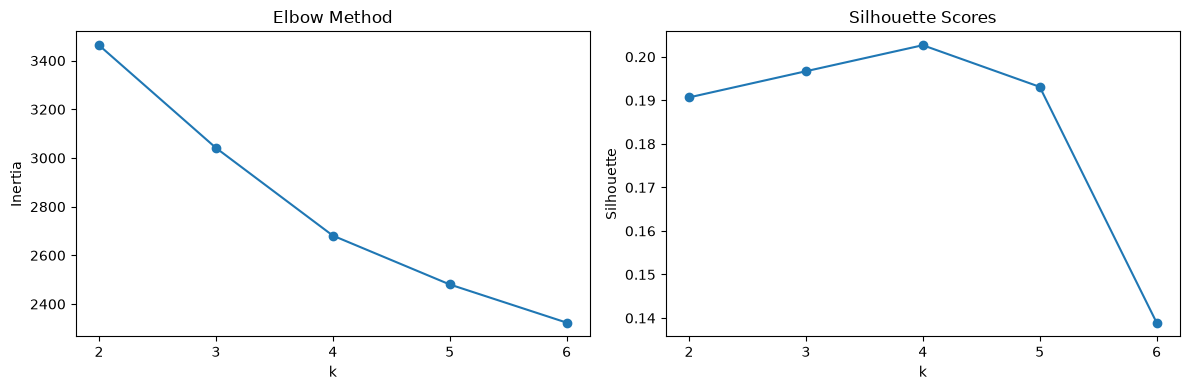

In [17]:
results = compare_cluster_counts(X_train_scaled)
display(results.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(results["k"], results["inertia"], marker="o")
axes[0].set(title="Elbow Method", xlabel="k", ylabel="Inertia")

axes[1].plot(results["k"], results["silhouette"], marker="o")
axes[1].set(
    title="Silhouette Scores",
    xlabel="k",
    ylabel="Silhouette",
)

for axis in axes:
    axis.set_xticks(results["k"])

plt.tight_layout()
plt.savefig(REPORTS / "figures" / "k_selection.png")
plt.show()

In [18]:
SELECTED_K = int(
    results.loc[results["silhouette"].idxmax(), "k"]
)

# You can change SELECTED_K after reviewing the results.
print("Selected k:", SELECTED_K)

kmeans = create_kmeans(SELECTED_K)
train_labels = kmeans.fit_predict(X_train_scaled)

clustering_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("kmeans", kmeans)
])

#use the fitted pipeline without fitting it again 
test_labels = clustering_pipeline.predict(test_data)

Selected k: 4


,patient_count,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,risk_category
Cluster,,,,,,,,,
0,149,121.15,74.31,37.83,130.58,39.91,0.57,29.88,low risk
1,266,106.40,66.92,23.49,110.64,28.17,0.43,26.10,low risk
2,33,161.79,71.70,31.52,435.18,35.63,0.56,32.88,High risk
3,166,139.17,78.97,27.80,129.86,31.60,0.43,46.54,low risk


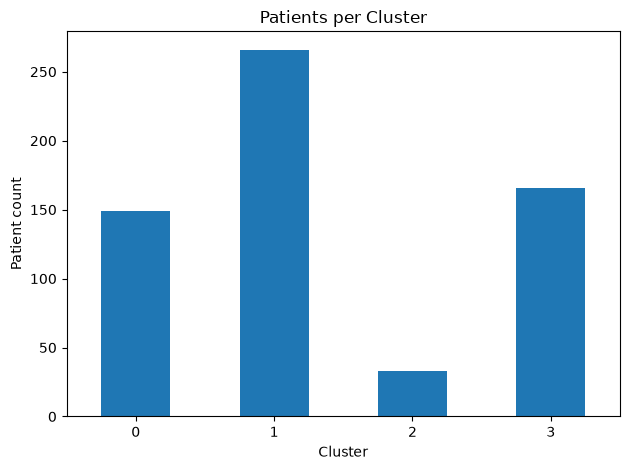

In [19]:
prepared_tran = preprocessor.named_steps["prepare"].transform(train_data)
imputed_train = preprocessor.named_steps["imputer"].transform(prepared_tran)

profiles = pd.DataFrame(
    imputed_train,
    columns=FEATURES,
    index=train_data.index
)

summary = summarize_clusters(profiles, train_labels)

high_risk = (
    (summary["Glucose"] > 126)
    & (summary["BMI"] > 30)
    & (summary["DiabetesPedigreeFunction"] > 0.5)
)

summary["risk_category"] = np.where(
    high_risk, "High risk", "low risk"
)

risk_mapping = summary["risk_category"].to_dict()

display(summary.round(2))

if not high_risk.any():
    print("No cluster meets all three high-risk thresholds.")

summary["patient_count"].plot.bar(
    title="Patients per Cluster",
    xlabel="Cluster",
    ylabel="Patient count",
    rot=0,
)
plt.tight_layout()
plt.savefig(REPORTS / "figures" / "cluster_sizes.png")
plt.show()

In [20]:
for data, labels, filename in [
    (train_data, train_labels, "train_labeled.csv"),
    (test_data, test_labels, "test_labeled.csv"),
]:
    labeled = data[FEATURES].copy()
    labeled["Cluster"] = labels
    labeled["risk_category"] = labeled["Cluster"].map(risk_mapping)

    labeled.to_csv(
        DATA / filename,
        index_label="source_row",
    )

bundle = {
    "pipeline": clustering_pipeline,
    "risk_mapping": risk_mapping,
    "features": FEATURES,
    "selected_k": SELECTED_K,
}

model_path = MODELS / "clustering_bundle.joblib"
joblib.dump(bundle, model_path)

results.to_csv(REPORTS / "metrics" / "kmeans_comparison.csv", index=False)
summary.to_csv(REPORTS / "metrics" / "cluster_summary.csv")

# Verify that saving and reloading preserves predictions.
loaded = joblib.load(model_path)

np.testing.assert_array_equal(
    loaded["pipeline"].predict(test_data),
    test_labels,
)

print("Clustering results saved and verified.")

Clustering results saved and verified.
